Running 1D...
Running 2D...
Running 3D...


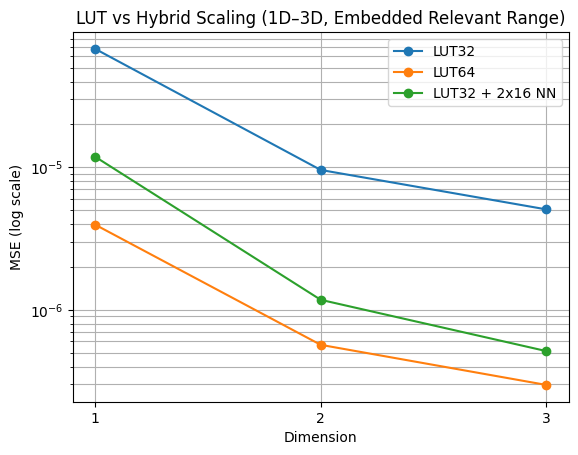


=== RESULTS ===
1D:
  LUT32     MSE: 6.780e-05
  LUT64     MSE: 3.957e-06
  Hybrid32  MSE: 1.186e-05

2D:
  LUT32     MSE: 9.589e-06
  LUT64     MSE: 5.680e-07
  Hybrid32  MSE: 1.176e-06

3D:
  LUT32     MSE: 5.072e-06
  LUT64     MSE: 2.972e-07
  Hybrid32  MSE: 5.136e-07



In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -------------------------------
# 1. Target functions
# -------------------------------
def f_1d(x):
    return np.sin(5*x) + 0.3*np.sin(20*x)

def f_2d(x, y):
    return np.sin(5*x)*np.cos(5*y) + np.exp(-50*((x-0.5)**2 + (y-0.5)**2))

def f_3d(x, y, z):
    return (
        np.sin(5*x)*np.cos(5*y)
        + 0.5*np.sin(4*z)*np.cos(3*x)
        + 0.2*np.exp(-30*((x-0.5)**2 + (y-0.5)**2 + (z-0.5)**2))
    )

# -------------------------------
# 2. LUT creation
# -------------------------------
def create_LUT(func, lut_size, dim):
    axes = [np.linspace(0, 1, lut_size) for _ in range(dim)]
    grid = np.meshgrid(*axes, indexing='ij')
    LUT = func(*grid)
    return LUT, axes

# -------------------------------
# 3. N-D LUT interpolation
# -------------------------------
def LUT_eval(LUT, axes, X):
    dim = X.shape[1]
    out = []

    for p in X:
        idx = []
        t = []

        for d in range(dim):
            a = axes[d]
            i = np.searchsorted(a, p[d]) - 1
            i = np.clip(i, 0, len(a)-2)

            t.append((p[d] - a[i]) / (a[i+1] - a[i]))
            idx.append(i)

        val = 0.0

        for c in range(2**dim):
            w = 1.0
            ind = []

            for d in range(dim):
                if (c >> d) & 1:
                    w *= t[d]
                    ind.append(idx[d] + 1)
                else:
                    w *= (1 - t[d])
                    ind.append(idx[d])

            val += w * LUT[tuple(ind)]

        out.append(val)

    return np.array(out)

# -------------------------------
# 4. NN residual model
# -------------------------------
def train_nn(X, residual):
    mean = residual.mean()
    std = residual.std() + 1e-8

    y = (residual - mean) / std

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X.shape[1],)),
        tf.keras.layers.Dense(16, activation='gelu'),
        tf.keras.layers.Dense(16, activation='gelu'),
        tf.keras.layers.Dense(1)
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

    model.fit(
        X, y,
        epochs=1500,
        batch_size=512,
        verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(patience=60, restore_best_weights=True)]
    )

    return model, mean, std

# -------------------------------
# 5. Run experiment
# -------------------------------
def run_case(func, dim, lut_size):

    X_train = np.random.rand(30000, dim)
    X_test = np.random.rand(15000, dim)

    y_train = func(*[X_train[:, i] for i in range(dim)])
    y_test = func(*[X_test[:, i] for i in range(dim)])

    LUT, axes = create_LUT(func, lut_size, dim)

    y_lut_train = LUT_eval(LUT, axes, X_train)
    y_lut_test = LUT_eval(LUT, axes, X_test)

    residual = y_train - y_lut_train
    nn, mean, std = train_nn(X_train, residual)

    nn_pred = nn.predict(X_test, verbose=0).reshape(-1)
    y_hybrid = y_lut_test + nn_pred * std + mean

    mse_lut = np.mean((y_lut_test - y_test)**2)
    mse_hybrid = np.mean((y_hybrid - y_test)**2)

    return mse_lut, mse_hybrid

# -------------------------------
# 6. Run all dimensions
# -------------------------------
dims = [1, 2, 3]

mse_lut32 = []
mse_lut64 = []
mse_hybrid32 = []

for d in dims:
    print(f"Running {d}D...")

    func = eval(f"f_{d}d")

    # LUT32
    ml32, _ = run_case(func, d, 32)

    # LUT64
    ml64, _ = run_case(func, d, 64)

    # Hybrid32
    _, mh32 = run_case(func, d, 32)

    mse_lut32.append(ml32)
    mse_lut64.append(ml64)
    mse_hybrid32.append(mh32)

# -------------------------------
# 7. Plot (IMPORTANT: only ticks 1,2,3)
# -------------------------------
plt.figure()

plt.plot(dims, mse_lut32, marker='o', label='LUT32')
plt.plot(dims, mse_lut64, marker='o', label='LUT64')
plt.plot(dims, mse_hybrid32, marker='o', label='LUT32 + 2x16 NN')

plt.yscale('log')
plt.xticks([1, 2, 3])  # IMPORTANT requirement
plt.xlabel("Dimension")
plt.ylabel("MSE (log scale)")
plt.title("LUT vs Hybrid Scaling (1D–3D, Embedded Relevant Range)")
plt.grid(True, which='both')
plt.legend()

plt.show()

# -------------------------------
# 8. Print results
# -------------------------------
print("\n=== RESULTS ===")
for i, d in enumerate(dims):
    print(f"{d}D:")
    print(f"  LUT32     MSE: {mse_lut32[i]:.3e}")
    print(f"  LUT64     MSE: {mse_lut64[i]:.3e}")
    print(f"  Hybrid32  MSE: {mse_hybrid32[i]:.3e}\n")